### Imports

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

### Configurations

In [70]:
data_path = "data/main.csv"

## Exploratory Data Analysis

In [71]:
db_main = pd.read_csv(data_path)
db_main.head()

C:\Users\ApoorvTripathi\AppData\Local\Temp\ipykernel_7928\3709795038.py:1: DtypeWarning: Columns (0: length_of_stay) have mixed types. Specify dtype option on import or set low_memory=False.
  db_main = pd.read_csv(data_path)


,health_service_area,hospital_county,operating_certificate_number,facility_id,facility_name,age_group,zip_code_3_digits,gender,race,ethnicity,...,apr_risk_of_mortality,apr_medical_surgical_description,payment_typology_1,birth_weight,abortion_edit_indicator,emergency_department_indicator,total_charges,total_costs,payment_typology_2,payment_typology_3
0,New York City,Bronx,7000001,1164,Bronx-Lebanon Hospital Center - Fulton Division,30 to 49,114,M,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,8225.00,7341.60,NaN,NaN
1,New York City,Bronx,7000002,1165,Jacobi Medical Center,30 to 49,104,M,Black/African American,Not Span/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,4846.76,2801.79,NaN,NaN
2,New York City,Bronx,7000002,1165,Jacobi Medical Center,0 to 17,104,M,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,17205.30,9945.95,Medicaid,NaN
3,New York City,Bronx,7000002,1165,Jacobi Medical Center,30 to 49,104,F,Black/African American,Not Span/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,9132.22,5279.11,NaN,NaN
4,New York City,Bronx,7000002,1165,Jacobi Medical Center,0 to 17,104,F,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,6645.30,3841.48,NaN,NaN


In [72]:
print(db_main.shape)

(1000000, 34)


In [73]:
db_main.describe()

,operating_certificate_number,facility_id,discharge_year,ccs_diagnosis_code,ccs_procedure_code,apr_drg_code,apr_mdc_code,apr_severity_of_illness_code,birth_weight,total_charges,total_costs
count,1.000000e+06,1000000.000000,1000000.0,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06
mean,7.001609e+06,1490.856136,2016.0,191.516350,127.461185,421.582554,10.456343,1.990971,332.030800,5.292492e+04,1.898598e+04
std,9.793396e+02,419.459043,0.0,163.821957,88.694905,242.140536,5.881602,0.897511,989.940043,1.010077e+05,4.057713e+04
min,7.000001e+06,1164.000000,2016.0,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000e-02,0.000000e+00
25%,7.001016e+06,1305.000000,2016.0,102.000000,45.000000,201.000000,5.000000,1.000000,0.000000,1.451412e+04,5.464167e+03
50%,7.002017e+06,1450.000000,2016.0,159.000000,137.000000,420.000000,10.000000,2.000000,0.000000,2.826889e+04,1.009367e+04
75%,7.002054e+06,1469.000000,2016.0,218.000000,218.000000,640.000000,15.000000,3.000000,0.000000,5.697177e+04,1.982524e+04
max,7.004010e+06,3975.000000,2016.0,999.000000,999.000000,956.000000,25.000000,4.000000,9000.000000,1.047750e+07,5.870820e+06


In [74]:
db_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 34 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   health_service_area                  1000000 non-null  str    
 1   hospital_county                      1000000 non-null  str    
 2   operating_certificate_number         1000000 non-null  int64  
 3   facility_id                          1000000 non-null  int64  
 4   facility_name                        1000000 non-null  str    
 5   age_group                            1000000 non-null  str    
 6   zip_code_3_digits                    984117 non-null   str    
 7   gender                               1000000 non-null  str    
 8   race                                 1000000 non-null  str    
 9   ethnicity                            1000000 non-null  str    
 10  length_of_stay                       1000000 non-null  object 
 11  type_of_ad

In [75]:
columns_for_the_table = [
    "health_service_area", 
    "age_group", 
    "gender", 
    "race", 
    "type_of_admission", 
    "patient_disposition", 
    "ccs_diagnosis_code", 
    "ccs_procedure_code", 
    "apr_drg_code", 
    "apr_mdc_code", 
    "apr_severity_of_illness_code", 
    "apr_risk_of_mortality", 
    "abortion_edit_indicator", 
    "emergency_department_indicator", 
    "length_of_stay"
]

### Selecting the features which are intuitively more important for the model and removing non relevant ones like payment and description features.

In [76]:
db = db_main[columns_for_the_table]
db.head()

,health_service_area,age_group,gender,race,type_of_admission,patient_disposition,ccs_diagnosis_code,ccs_procedure_code,apr_drg_code,apr_mdc_code,apr_severity_of_illness_code,apr_risk_of_mortality,abortion_edit_indicator,emergency_department_indicator,length_of_stay
0,New York City,30 to 49,M,Other Race,Emergency,Home or Self Care,657,0,753,19,1,Minor,N,Y,3
1,New York City,30 to 49,M,Black/African American,Emergency,Home or Self Care,657,218,753,19,1,Minor,N,Y,3
2,New York City,0 to 17,M,Other Race,Emergency,Home or Self Care,128,231,141,4,2,Minor,N,Y,3
3,New York City,30 to 49,F,Black/African American,Emergency,Home or Self Care,657,218,753,19,1,Minor,N,Y,6
4,New York City,0 to 17,F,Other Race,Emergency,Home or Self Care,128,231,141,4,1,Minor,N,Y,1


### Check Null Values

In [77]:
db.isna().sum()

health_service_area                0
age_group                          0
gender                             0
race                               0
type_of_admission                  0
patient_disposition                0
ccs_diagnosis_code                 0
ccs_procedure_code                 0
apr_drg_code                       0
apr_mdc_code                       0
apr_severity_of_illness_code       0
apr_risk_of_mortality             31
abortion_edit_indicator            0
emergency_department_indicator     0
length_of_stay                     0
dtype: int64

### Check the destribution of each feature

### Destribution of categorical data

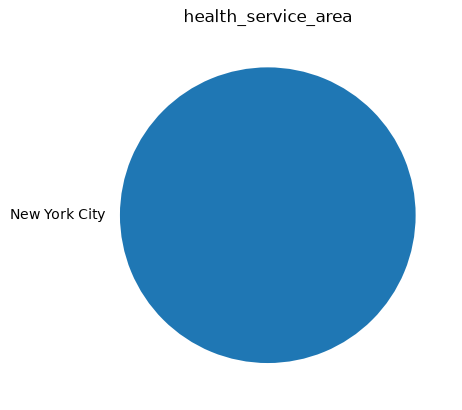

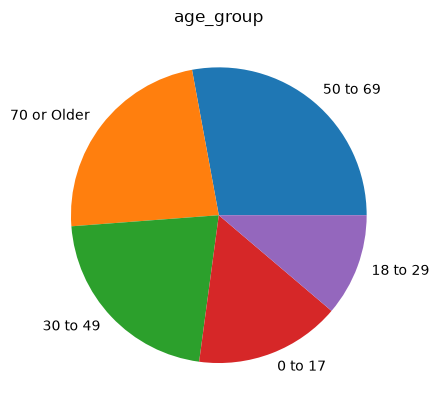

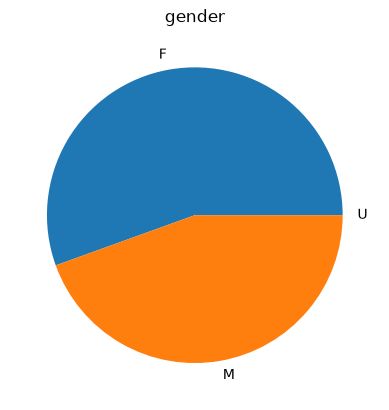

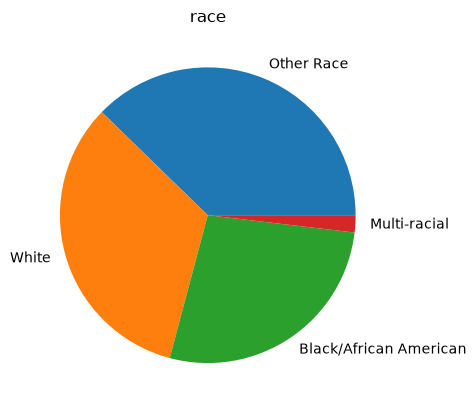

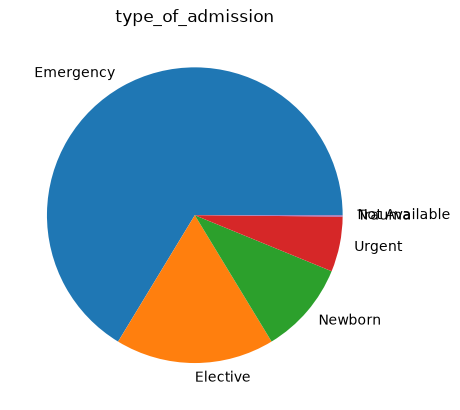

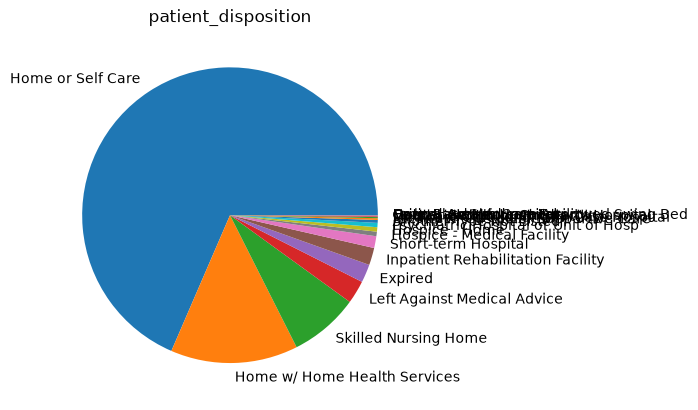

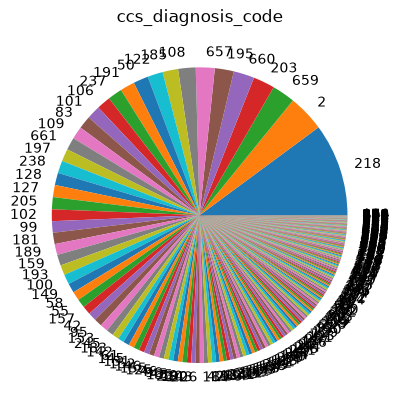

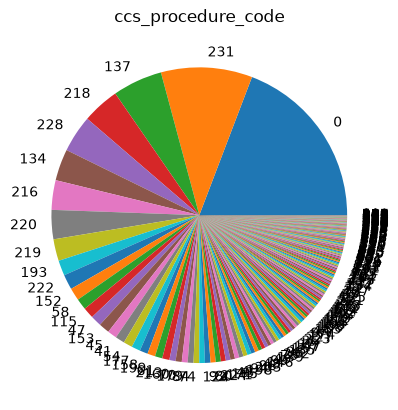

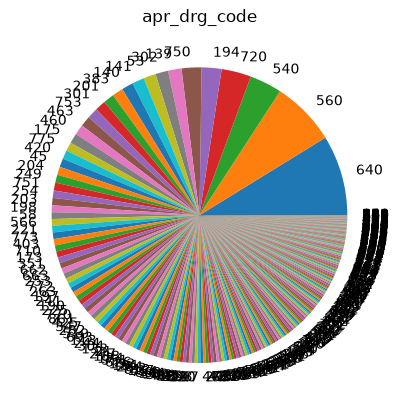

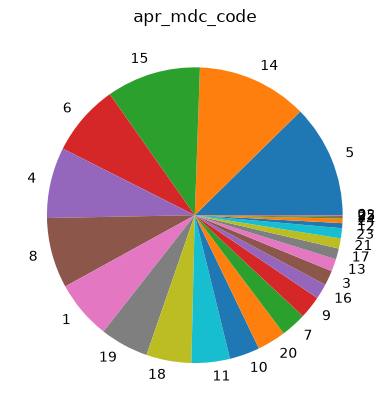

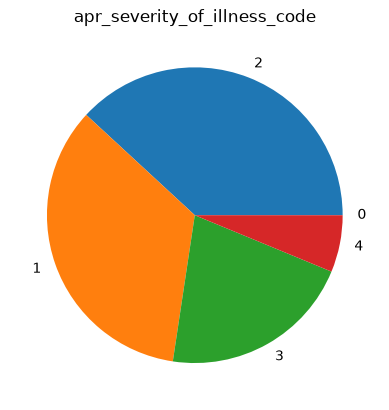

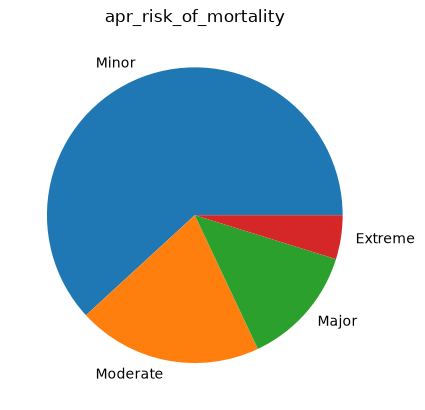

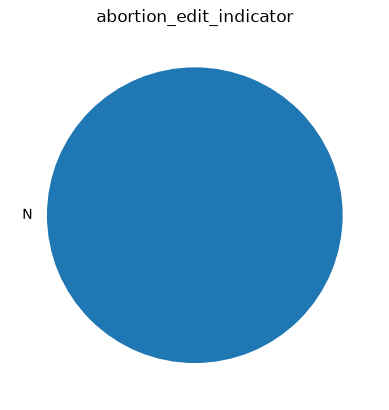

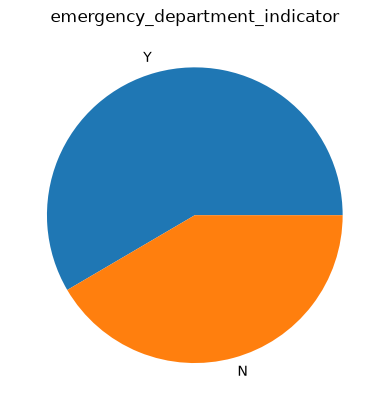

In [78]:
plots_to_make = [
    "health_service_area",
    "age_group",
    "gender",
    "race",
    "type_of_admission",
    "patient_disposition",
    "ccs_diagnosis_code",
    "ccs_procedure_code",
    "apr_drg_code",
    "apr_mdc_code",
    "apr_severity_of_illness_code",
    "apr_risk_of_mortality",
    "abortion_edit_indicator",
    "emergency_department_indicator"
]
for i in plots_to_make:
    counts_for_hs = db[i].value_counts()
    labels = counts_for_hs.index
    values = counts_for_hs.values

# Plot the chart
    plt.pie(values, labels=labels)
    plt.title(i)
    plt.show()

In [79]:
codes_features = ["ccs_diagnosis_code", "ccs_procedure_code", "apr_drg_code", "apr_mdc_code"]
for i in codes_features:
    print(f"Unique categories in {i}: {db[i].nunique()}")


Unique categories in ccs_diagnosis_code: 260
Unique categories in ccs_procedure_code: 224
Unique categories in apr_drg_code: 314
Unique categories in apr_mdc_code: 26


In [80]:

# Splitting the DataFrame into features and target columns
x = db.iloc[:, 0:-1]
y = db.iloc[:,-1]

# Fixing  the data type and formatting of the target column
y = y.astype(str).replace("120 +","120", regex=False).astype(int).to_frame()

# Performing train test split
x_train, x_test, y_train, y_test = train_test_split(x,y)

## Preprocessing Data using columns transformer
1. One Hot Encoder: For features with less number of unique values
2. Target Encoder: For features with a lot of unique values

In [81]:
# 1. Grouping columns
columns_for_one_hot = [
    "health_service_area",
    "age_group",
    "gender",
    "race",
    "type_of_admission",
    "patient_disposition",
    "apr_severity_of_illness_code",
    "apr_risk_of_mortality",
    "abortion_edit_indicator",
    "emergency_department_indicator"
]
columns_for_target = [
    "ccs_diagnosis_code", 
    "ccs_procedure_code", 
    "apr_drg_code", 
    "apr_mdc_code"
]

preprocessing  = ColumnTransformer([
    ("one_hot", OneHotEncoder(dtype=int,sparse_output=False, handle_unknown="ignore"),columns_for_one_hot),
    ("target_ecoder", TargetEncoder(target_type="continuous", smooth="auto", cv=5),columns_for_target),
    ], remainder="passthrough", verbose_feature_names_out=False)


## Creating the Pipeline

In [82]:
pipe = Pipeline([("preprocessor", preprocessing)])
pipe.set_output(transform="pandas")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot', ...), ('target_ecoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: b

### Passing the data thrugh the transformation pipeline

In [83]:
x_train = pipe.fit_transform(x_train, y_train).reset_index(drop=True)
x_test = pipe.transform(x_test).reset_index(drop=True)

c:\Users\ApoorvTripathi\Desktop\length-of-stay-prediction-using-icp-codes\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [84]:
x_train.head()

,health_service_area_New York City,age_group_0 to 17,age_group_18 to 29,age_group_30 to 49,age_group_50 to 69,age_group_70 or Older,gender_F,gender_M,gender_U,race_Black/African American,...,apr_risk_of_mortality_Minor,apr_risk_of_mortality_Moderate,apr_risk_of_mortality_nan,abortion_edit_indicator_N,emergency_department_indicator_N,emergency_department_indicator_Y,ccs_diagnosis_code,ccs_procedure_code,apr_drg_code,apr_mdc_code
0,1,0,1,0,0,0,0,1,0,0,...,1,0,0,1,0,1,4.706336,4.977301,4.161953,4.908043
1,1,0,0,0,0,1,1,0,0,0,...,0,0,0,1,1,0,12.503025,11.359095,7.625674,5.663058
2,1,0,0,1,0,0,1,0,0,0,...,1,0,0,1,0,1,2.884279,3.930464,3.949104,2.993468
3,1,1,0,0,0,0,0,1,0,0,...,1,0,0,1,1,0,3.798405,2.925825,2.441603,3.844089
4,1,1,0,0,0,0,0,1,0,0,...,1,0,0,1,1,0,3.823784,2.596351,2.439448,3.870801


In [85]:
x_train.to_csv("data/x_train.csv", index=False)
y_train.to_csv("data/y_train.csv", index=False)
x_test.to_csv("data/x_test.csv", index=False)
y_test.to_csv("data/y_test.csv", index=False)